In [ ]:
# Restaurant Growth Advisor

## Objective
Analyze restaurant ratings, customer preferences, cuisines, and restaurant attributes to identify factors driving restaurant success.

## Key Questions
1. Which cuisines receive the highest ratings?
2. Which restaurant features influence ratings?
3. What customer segments give higher ratings?
4. Which cities have the best-performing restaurants?
5. What recommendations can be given to restaurants?

In [8]:
!find /kaggle/input -type f

/kaggle/input/datasets/mehmakaur/restaurant/chefmozcuisine.csv
/kaggle/input/datasets/mehmakaur/restaurant/chefmozhours4.csv
/kaggle/input/datasets/mehmakaur/restaurant/rating_final.csv
/kaggle/input/datasets/mehmakaur/restaurant/userprofile.csv
/kaggle/input/datasets/mehmakaur/restaurant/README
/kaggle/input/datasets/mehmakaur/restaurant/chefmozaccepts.csv
/kaggle/input/datasets/mehmakaur/restaurant/chefmozparking.csv
/kaggle/input/datasets/mehmakaur/restaurant/geoplaces2.csv
/kaggle/input/datasets/mehmakaur/restaurant/usercuisine.csv
/kaggle/input/datasets/mehmakaur/restaurant/userpayment.csv
/kaggle/input/datasets/mehmakaur/details/restaurant_cuisine.csv.xlsx
/kaggle/input/datasets/mehmakaur/details/consumers.csv.xlsx
/kaggle/input/datasets/mehmakaur/details/ratings.csv.xlsx
/kaggle/input/datasets/mehmakaur/details/restaurants.csv.xlsx


In [5]:
import pandas as pd

restaurants = pd.read_csv(
    '/kaggle/input/datasets/mehmakaur/restaurant/geoplaces2.csv'
)

ratings = pd.read_csv(
    '/kaggle/input/datasets/mehmakaur/restaurant/rating_final.csv'
)

consumers = pd.read_csv(
    '/kaggle/input/datasets/mehmakaur/restaurant/userprofile.csv'
)

cuisine = pd.read_csv(
    '/kaggle/input/datasets/mehmakaur/restaurant/chefmozcuisine.csv'
)

print(restaurants.shape)
print(ratings.shape)
print(consumers.shape)
print(cuisine.shape)

(130, 21)
(1161, 5)
(138, 19)
(916, 2)


In [6]:
print(restaurants.columns.tolist())
print(ratings.columns.tolist())
print(consumers.columns.tolist())
print(cuisine.columns.tolist())

['placeID', 'latitude', 'longitude', 'the_geom_meter', 'name', 'address', 'city', 'state', 'country', 'fax', 'zip', 'alcohol', 'smoking_area', 'dress_code', 'accessibility', 'price', 'url', 'Rambience', 'franchise', 'area', 'other_services']
['userID', 'placeID', 'rating', 'food_rating', 'service_rating']
['userID', 'latitude', 'longitude', 'smoker', 'drink_level', 'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos', 'birth_year', 'interest', 'personality', 'religion', 'activity', 'color', 'weight', 'budget', 'height']
['placeID', 'Rcuisine']


In [7]:
print("Restaurants Shape:", restaurants.shape)
print("Ratings Shape:", ratings.shape)
print("Consumers Shape:", consumers.shape)
print("Cuisine Shape:", cuisine.shape)

restaurants.head()

Restaurants Shape: (130, 21)
Ratings Shape: (1161, 5)
Consumers Shape: (138, 19)
Cuisine Shape: (916, 2)


,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,No_Alcohol_Served,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,...,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none
2,135106,22.149709,-100.976093,0101000020957F0000649D6F21634858C119AE9BF528A3...,El Rinc�n de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,?,...,Wine-Beer,only at bar,informal,partially,medium,?,familiar,f,open,none
3,132667,23.752697,-99.163359,0101000020957F00005D67BCDDED8157C1222A2DC8D84D...,little pizza Emilio Portes Gil,calle emilio portes gil,victoria,tamaulipas,?,?,...,No_Alcohol_Served,none,informal,completely,low,?,familiar,t,closed,none
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,No_Alcohol_Served,permitted,informal,completely,medium,?,familiar,t,closed,none


In [8]:
ratings.head()

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2


In [9]:
consumers.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,false,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


In [10]:
cuisine.head()

,placeID,Rcuisine
0,135110,Spanish
1,135109,Italian
2,135107,Latin_American
3,135106,Mexican
4,135105,Fast_Food


In [11]:
print("Restaurants")
print(restaurants.isnull().sum())

print("\nRatings")
print(ratings.isnull().sum())

print("\nConsumers")
print(consumers.isnull().sum())

print("\nCuisine")
print(cuisine.isnull().sum())

Restaurants
placeID           0
latitude          0
longitude         0
the_geom_meter    0
name              0
address           0
city              0
state             0
country           0
fax               0
zip               0
alcohol           0
smoking_area      0
dress_code        0
accessibility     0
price             0
url               0
Rambience         0
franchise         0
area              0
other_services    0
dtype: int64

Ratings
userID            0
placeID           0
rating            0
food_rating       0
service_rating    0
dtype: int64

Consumers
userID              0
latitude            0
longitude           0
smoker              0
drink_level         0
dress_preference    0
ambience            0
transport           0
marital_status      0
hijos               0
birth_year          0
interest            0
personality         0
religion            0
activity            0
color               0
weight              0
budget              0
height              0
dtyp

In [12]:
print("Restaurant Duplicates:", restaurants.duplicated().sum())
print("Ratings Duplicates:", ratings.duplicated().sum())
print("Consumers Duplicates:", consumers.duplicated().sum())
print("Cuisine Duplicates:", cuisine.duplicated().sum())

Restaurant Duplicates: 0
Ratings Duplicates: 0
Consumers Duplicates: 0
Cuisine Duplicates: 0


In [13]:
restaurant_ratings = pd.merge(
    ratings,
    restaurants,
    on='placeID',
    how='left'
)

restaurant_ratings.head()

,userID,placeID,rating,food_rating,service_rating,latitude,longitude,the_geom_meter,name,address,...,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services
0,U1077,135085,2,2,2,22.150802,-100.982680,0101000020957F00009F823DA6094858C18A2D4D37F9A4...,Tortas Locas Hipocampo,Venustiano Carranza 719 Centro,...,No_Alcohol_Served,not permitted,informal,no_accessibility,medium,?,familiar,f,closed,none
1,U1077,135038,2,2,1,22.155651,-100.977767,0101000020957F0000506149736E4758C1A8BC93DA48A3...,Restaurant la Chalita,Guajardo Sn San Luis Potosi Centro,...,No_Alcohol_Served,section,informal,no_accessibility,medium,?,familiar,f,closed,none
2,U1077,132825,2,2,2,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,...,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none
3,U1077,135060,1,2,2,22.156883,-100.978485,0101000020957F00004C95C918394758C17A5C44896AA3...,Restaurante Marisco Sam,Ignacio Allende 785 Centro,...,No_Alcohol_Served,none,informal,no_accessibility,medium,?,familiar,f,closed,none
4,U1068,135104,1,1,2,23.752982,-99.168434,0101000020957F00007CDF5EAFC58157C1645743B23E4F...,vips,?,...,Full_Bar,not permitted,informal,completely,medium,?,familiar,t,closed,variety


In [14]:
restaurant_data = pd.merge(
    restaurant_ratings,
    cuisine,
    on='placeID',
    how='left'
)

restaurant_data.head()

,userID,placeID,rating,food_rating,service_rating,latitude,longitude,the_geom_meter,name,address,...,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services,Rcuisine
0,U1077,135085,2,2,2,22.150802,-100.982680,0101000020957F00009F823DA6094858C18A2D4D37F9A4...,Tortas Locas Hipocampo,Venustiano Carranza 719 Centro,...,not permitted,informal,no_accessibility,medium,?,familiar,f,closed,none,Fast_Food
1,U1077,135038,2,2,1,22.155651,-100.977767,0101000020957F0000506149736E4758C1A8BC93DA48A3...,Restaurant la Chalita,Guajardo Sn San Luis Potosi Centro,...,section,informal,no_accessibility,medium,?,familiar,f,closed,none,NaN
2,U1077,132825,2,2,2,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,...,none,informal,completely,low,?,familiar,f,open,none,Mexican
3,U1077,135060,1,2,2,22.156883,-100.978485,0101000020957F00004C95C918394758C17A5C44896AA3...,Restaurante Marisco Sam,Ignacio Allende 785 Centro,...,none,informal,no_accessibility,medium,?,familiar,f,closed,none,Seafood
4,U1068,135104,1,1,2,23.752982,-99.168434,0101000020957F00007CDF5EAFC58157C1645743B23E4F...,vips,?,...,not permitted,informal,completely,medium,?,familiar,t,closed,variety,Mexican


In [15]:
full_data = pd.merge(
    restaurant_data,
    consumers,
    on='userID',
    how='left'
)

full_data.head()

,userID,placeID,rating,food_rating,service_rating,latitude_x,longitude_x,the_geom_meter,name,address,...,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1077,135085,2,2,2,22.150802,-100.982680,0101000020957F00009F823DA6094858C18A2D4D37F9A4...,Tortas Locas Hipocampo,Venustiano Carranza 719 Centro,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
1,U1077,135038,2,2,1,22.155651,-100.977767,0101000020957F0000506149736E4758C1A8BC93DA48A3...,Restaurant la Chalita,Guajardo Sn San Luis Potosi Centro,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
2,U1077,132825,2,2,2,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
3,U1077,135060,1,2,2,22.156883,-100.978485,0101000020957F00004C95C918394758C17A5C44896AA3...,Restaurante Marisco Sam,Ignacio Allende 785 Centro,...,kids,1987,technology,thrifty-protector,Catholic,student,blue,65,medium,1.71
4,U1068,135104,1,1,2,23.752982,-99.168434,0101000020957F00007CDF5EAFC58157C1645743B23E4F...,vips,?,...,independent,1988,technology,thrifty-protector,Catholic,student,blue,72,low,1.57


In [16]:
print(full_data.shape)

full_data.info()

(1331, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1331 entries, 0 to 1330
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userID            1331 non-null   object 
 1   placeID           1331 non-null   int64  
 2   rating            1331 non-null   int64  
 3   food_rating       1331 non-null   int64  
 4   service_rating    1331 non-null   int64  
 5   latitude_x        1331 non-null   float64
 6   longitude_x       1331 non-null   float64
 7   the_geom_meter    1331 non-null   object 
 8   name              1331 non-null   object 
 9   address           1331 non-null   object 
 10  city              1331 non-null   object 
 11  state             1331 non-null   object 
 12  country           1331 non-null   object 
 13  fax               1331 non-null   object 
 14  zip               1331 non-null   object 
 15  alcohol           1331 non-null   object 
 16  smoking_area      1331 non-null

In [18]:
full_data['Success_Score'] = (
    full_data['rating'] +
    full_data['food_rating'] +
    full_data['service_rating']
) / 3

In [19]:
def rating_category(x):
    if x >= 1.5:
        return "High"
    elif x >= 1:
        return "Medium"
    else:
        return "Low"

full_data['Success_Category'] = full_data['Success_Score'].apply(rating_category)

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

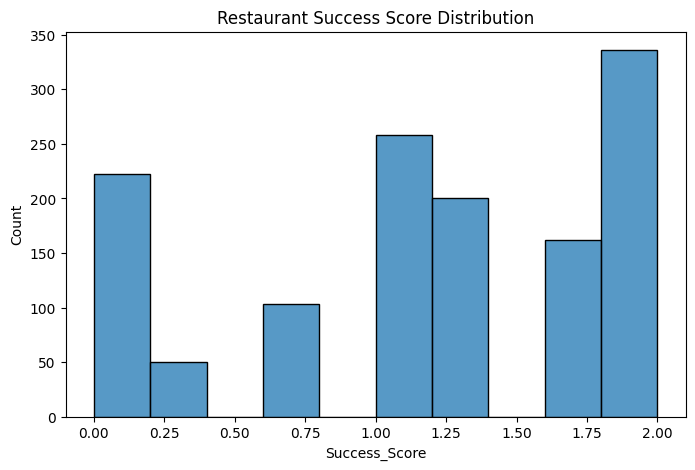

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(full_data['Success_Score'], bins=10)
plt.title('Restaurant Success Score Distribution')
plt.show()

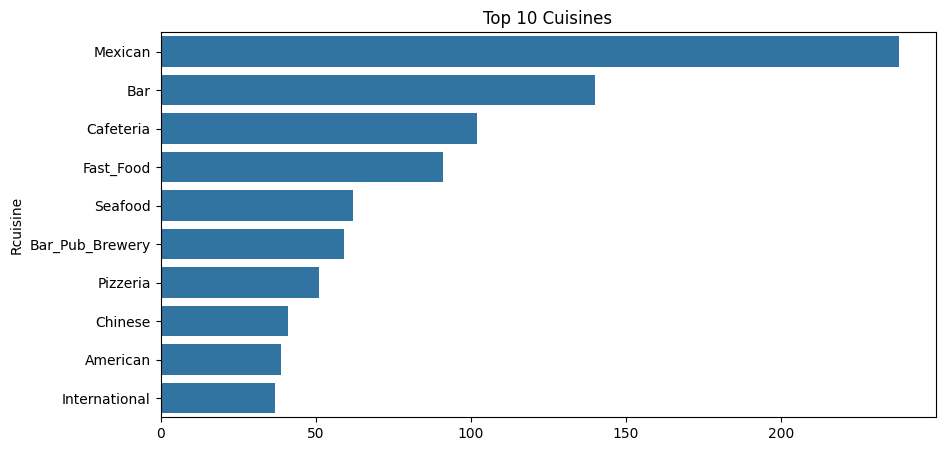

In [22]:
top_cuisine = full_data['Rcuisine'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_cuisine.values,
    y=top_cuisine.index
)
plt.title('Top 10 Cuisines')
plt.show()

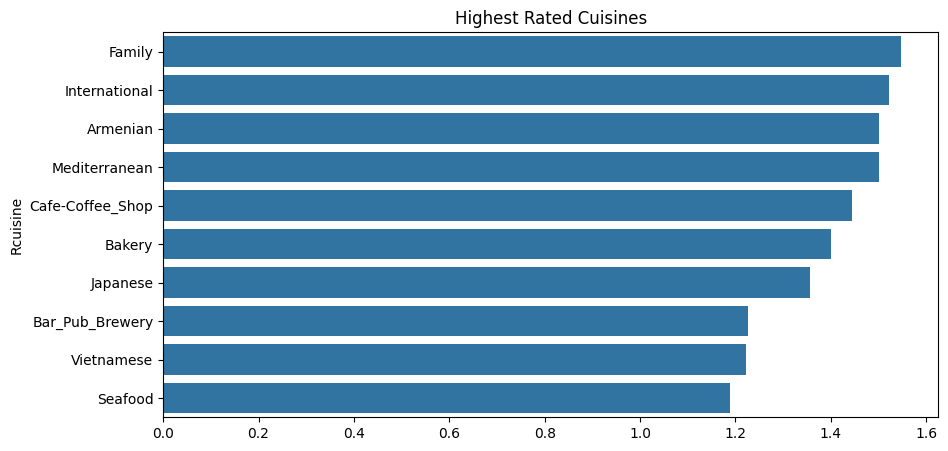

In [23]:
cuisine_rating = full_data.groupby(
    'Rcuisine'
)['Success_Score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=cuisine_rating.values,
    y=cuisine_rating.index
)
plt.title('Highest Rated Cuisines')
plt.show()

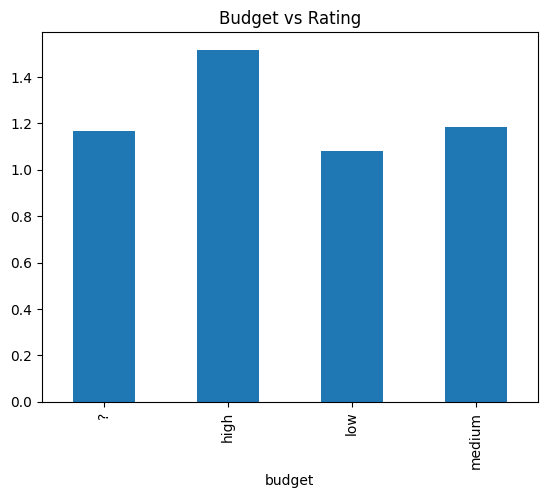

In [24]:
budget_rating = full_data.groupby(
    'budget'
)['Success_Score'].mean()

budget_rating.plot(kind='bar')

plt.title("Budget vs Rating")
plt.show()

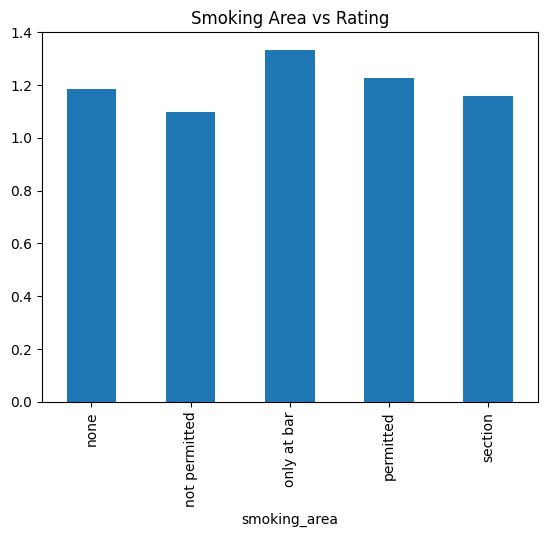

In [25]:
smoking_rating = full_data.groupby(
    'smoking_area'
)['Success_Score'].mean()

smoking_rating.plot(kind='bar')

plt.title("Smoking Area vs Rating")
plt.show()

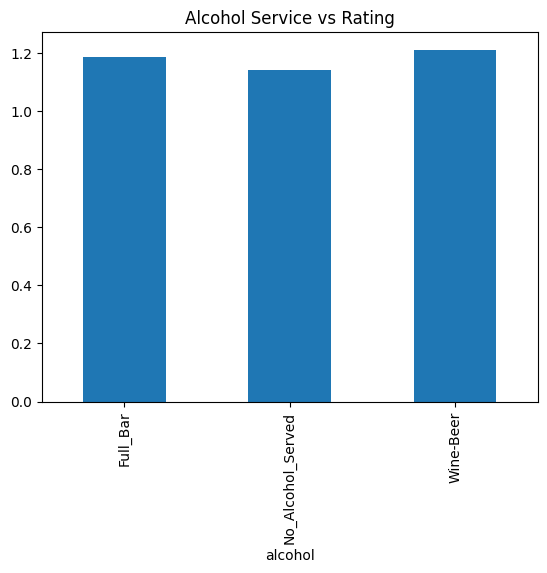

In [27]:
alcohol_rating = full_data.groupby(
    'alcohol'
)['Success_Score'].mean()

alcohol_rating.plot(kind='bar')

plt.title("Alcohol Service vs Rating")
plt.show()

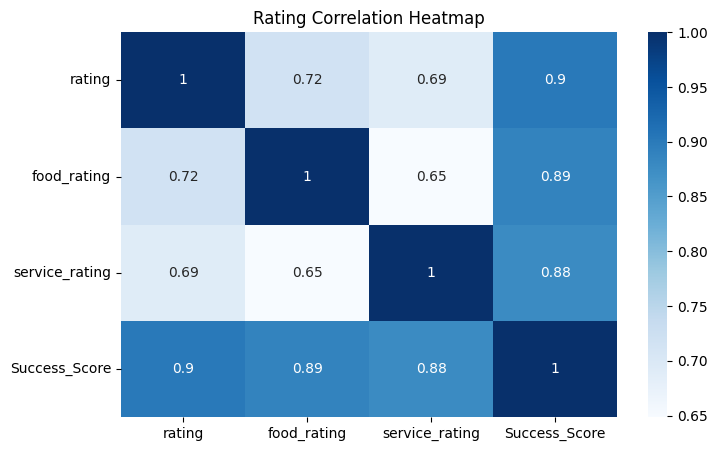

In [28]:
plt.figure(figsize=(8,5))

sns.heatmap(
    full_data[['rating',
               'food_rating',
               'service_rating',
               'Success_Score']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Rating Correlation Heatmap')
plt.show()

In [29]:
top_restaurants = full_data.groupby(
    'name'
)['Success_Score'].mean().sort_values(
    ascending=False
).head(10)

print(top_restaurants)

name
Restaurant Las Mananitas                   2.000000
emilianos                                  1.866667
Michiko Restaurant Japones                 1.866667
Giovannis                                  1.833333
La Estrella de Dimas                       1.800000
Restaurante la Parroquia Potosina          1.750000
cafe punta del cielo                       1.722222
la Cochinita Pibil Restaurante Yucateco    1.714286
Mariscos El Pescador                       1.615385
Kiku Cuernavaca                            1.600000
Name: Success_Score, dtype: float64


Dataset Shape: (1043, 7)

Features:
   price  alcohol  smoking_area  budget  transport  Rcuisine
0      2        1             1       3          3        12
2      1        1             0       3          3        18
3      2        1             0       3          3        21
4      2        0             1       2          3        18
5      1        1             3       2          3        18

Target:
0    0
2    0
3    0
4    2
5    1
Name: Success_Category, dtype: int64

Accuracy:
41.15 %

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.49      0.48        84
           1       0.36      0.31      0.33        59
           2       0.37      0.41      0.39        66

    accuracy                           0.41       209
   macro avg       0.40      0.40      0.40       209
weighted avg       0.41      0.41      0.41       209



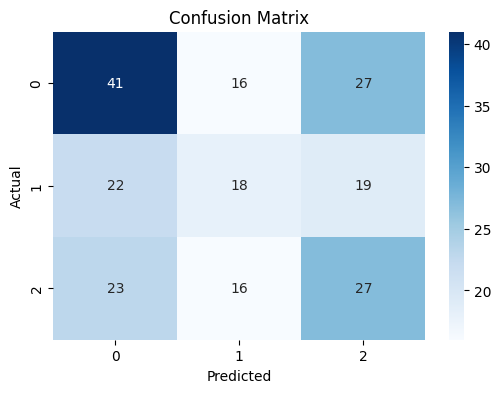


Feature Importance:
        Feature  Importance
5      Rcuisine    0.368500
4     transport    0.164550
2  smoking_area    0.138404
3        budget    0.135467
0         price    0.104581
1       alcohol    0.088499


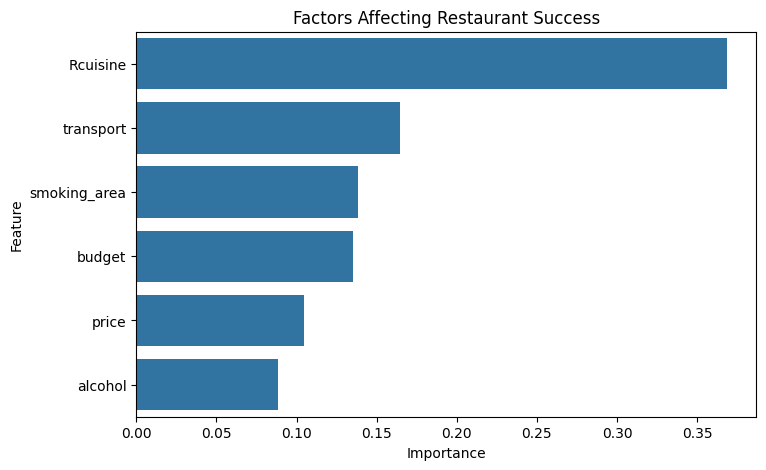


Sample Predictions:
      Actual  Predicted
1321       2          1
382        1          2
716        2          0
1062       0          2
848        1          0
1254       0          2
747        0          2
303        2          0
1066       0          0
730        0          0


In [44]:
# ==========================================
# MACHINE LEARNING
# RESTAURANT SUCCESS PREDICTION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# SELECT FEATURES
# ==========================================

ml_data = full_data[
    [
        'price',
        'alcohol',
        'smoking_area',
        'budget',
        'transport',
        'Rcuisine',
        'Success_Category'
    ]
].copy()

# ==========================================
# REMOVE MISSING VALUES
# ==========================================

ml_data.dropna(inplace=True)

print("Dataset Shape:", ml_data.shape)

# ==========================================
# ENCODE ALL CATEGORICAL COLUMNS
# ==========================================

feature_encoders = {}

for col in ml_data.columns:

    le = LabelEncoder()

    ml_data[col] = le.fit_transform(
        ml_data[col].astype(str)
    )

    feature_encoders[col] = le

# ==========================================
# FEATURES & TARGET
# ==========================================

X = ml_data.drop(
    'Success_Category',
    axis=1
)

y = ml_data['Success_Category']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# RANDOM FOREST MODEL
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = rf.predict(X_test)

# ==========================================
# ACCURACY
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# ==========================================
# FEATURE IMPORTANCE CHART
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Factors Affecting Restaurant Success'
)

plt.show()

# ==========================================
# SAMPLE PREDICTIONS
# ==========================================

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nSample Predictions:")
print(results.head(10))